#Начальные установки

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# отображать графики прямо в коде
%matplotlib inline
import scipy
import scipy.stats as stats
import seaborn as sns
import sklearn.linear_model as lm
import math

pd.options.display.max_rows = 9 # максимальное количество строк при отображении датафрейма

## Импорт данных

In [106]:
from google.colab import files
files.upload()

Saving medical_expenses_data.csv to medical_expenses_data (2).csv


{'medical_expenses_data (2).csv': b'age,sex,bmi,children,smoker,region,charges\r\n19,female,27.9,0,yes,southwest,16884.924\r\n18,male,33.77,1,no,southeast,1725.5523\r\n28,male,33,3,no,southeast,4449.462\r\n33,male,22.705,0,no,northwest,21984.47061\r\n32,male,28.88,0,no,northwest,3866.8552\r\n31,female,25.74,0,no,southeast,3756.6216\r\n46,female,33.44,1,no,southeast,8240.5896\r\n37,female,27.74,3,no,northwest,7281.5056\r\n37,male,29.83,2,no,northeast,6406.4107\r\n60,female,25.84,0,no,northwest,28923.13692\r\n25,male,26.22,0,no,northeast,2721.3208\r\n62,female,26.29,0,yes,southeast,27808.7251\r\n23,male,34.4,0,no,southwest,1826.843\r\n56,female,39.82,0,no,southeast,11090.7178\r\n27,male,42.13,0,yes,southeast,39611.7577\r\n19,male,24.6,1,no,southwest,1837.237\r\n52,female,30.78,1,no,northeast,10797.3362\r\n23,male,23.845,0,no,northeast,2395.17155\r\n56,male,40.3,0,no,southwest,10602.385\r\n30,male,35.3,0,yes,southwest,36837.467\r\n60,female,36.005,0,no,northeast,13228.84695\r\n30,female,3

In [107]:
df = pd.read_csv("medical_expenses_data.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
...,...,...,...,...,...,...,...
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


##Первичное обследование данных

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [109]:
df.value_counts()

age  sex     bmi    children  smoker  region     charges    
19   male    30.59  0         no      northwest  1639.56310     2
48   female  25.85  3         yes     southeast  24180.93350    1
             22.80  0         no      southwest  8269.04400     1
47   male    47.52  1         no      southeast  8083.91980     1
                                                               ..
30   male    38.83  1         no      southeast  18963.17192    1
             37.80  2         yes     southwest  39241.44200    1
             37.43  3         no      northeast  5428.72770     1
31   female  29.26  1         no      southeast  4350.51440     1
Name: count, Length: 1337, dtype: int64

# Предварительная обработка

In [110]:
# поиск дубликатов
df.duplicated().sum()

np.int64(1)

In [111]:
# удаление полных дубликатов
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [112]:
# предварительный осмотр датафрейма
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


##Уникальные значения

In [113]:
# возраст застрахованного лица
arr_unique_age = df['age'].unique(); arr_unique_age

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39])

In [114]:
# пол застрахованного лица
arr_unique_sex = df['sex'].unique(); arr_unique_sex

array(['female', 'male'], dtype=object)

In [115]:
# индекс массы тела (кг/м2), в идеале от 18,5 до 25
arr_unique_bmi = df['bmi'].unique()
print(f'Количество незаполненных значений признак isna : {df['bmi'].isna().sum()}')
arr_unique_bmi

Количество незаполненных значений признак isna : 0


array([27.9  , 33.77 , 33.   , 22.705, 28.88 , 25.74 , 33.44 , 27.74 ,
       29.83 , 25.84 , 26.22 , 26.29 , 34.4  , 39.82 , 42.13 , 24.6  ,
       30.78 , 23.845, 40.3  , 35.3  , 36.005, 32.4  , 34.1  , 31.92 ,
       28.025, 27.72 , 23.085, 32.775, 17.385, 36.3  , 35.6  , 26.315,
       28.6  , 28.31 , 36.4  , 20.425, 32.965, 20.8  , 36.67 , 39.9  ,
       26.6  , 36.63 , 21.78 , 30.8  , 37.05 , 37.3  , 38.665, 34.77 ,
       24.53 , 35.2  , 35.625, 33.63 , 28.   , 34.43 , 28.69 , 36.955,
       31.825, 31.68 , 22.88 , 37.335, 27.36 , 33.66 , 24.7  , 25.935,
       22.42 , 28.9  , 39.1  , 36.19 , 23.98 , 24.75 , 28.5  , 28.1  ,
       32.01 , 27.4  , 34.01 , 29.59 , 35.53 , 39.805, 26.885, 38.285,
       37.62 , 41.23 , 34.8  , 22.895, 31.16 , 27.2  , 26.98 , 39.49 ,
       24.795, 31.3  , 38.28 , 19.95 , 19.3  , 31.6  , 25.46 , 30.115,
       29.92 , 27.5  , 28.4  , 30.875, 27.94 , 35.09 , 29.7  , 35.72 ,
       32.205, 28.595, 49.06 , 27.17 , 23.37 , 37.1  , 23.75 , 28.975,
      

In [116]:
# Число детей охваченных медицинской страховкой
arr_unique_ch = df['children'].unique(); arr_unique_ch

array([0, 1, 3, 2, 5, 4])

In [117]:
# Курильщик
arr_unique_smoker = df['smoker'].unique(); arr_unique_smoker

array(['yes', 'no'], dtype=object)

In [118]:
# Регион застрахованного лица
arr_unique_region = df['region'].unique(); arr_unique_region

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [119]:
#Размер индивидуальных мед.расходов
arr_unique_charges = df['charges'].unique()
print(f'Количество незаполненных значений признак isna : {df['charges'].isna().sum()}')
arr_unique_charges

Количество незаполненных значений признак isna : 0


array([16884.924 ,  1725.5523,  4449.462 , ...,  1629.8335,  2007.945 ,
       29141.3603])

Датафрейм содержит следующие виды признаков:
* Категориальный: Пол (sex), Курильщик (smoker), Регион (region)
* Количественный(непрерывный) : Индекс массы тела (bmi), Размер индивидуальных мед.расходов - Выплаты (charges), Число детей (children)
* Количественный (дискретный) : Возраст (age)

#Информативная визуализация

## Построение графиков, гистограмм

### Количественный (дискретный)

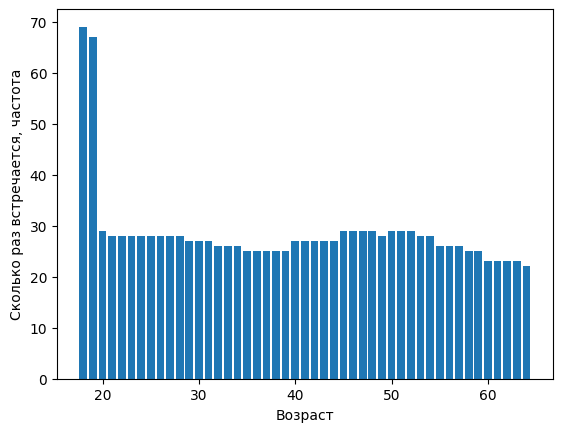

In [120]:
ages = df['age'].value_counts().sort_index()
plt.bar(ages.index, ages.values)
plt.xlabel('Возраст')
plt.ylabel('Сколько раз встречается, частота')
plt.show()

###Количественный (непрерывный)

<Axes: >

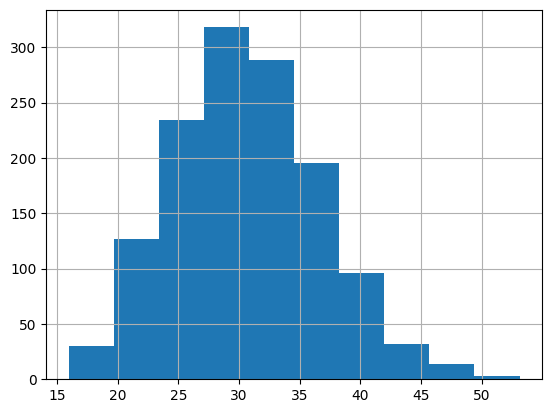

In [121]:
df['bmi'].hist()

<Axes: >

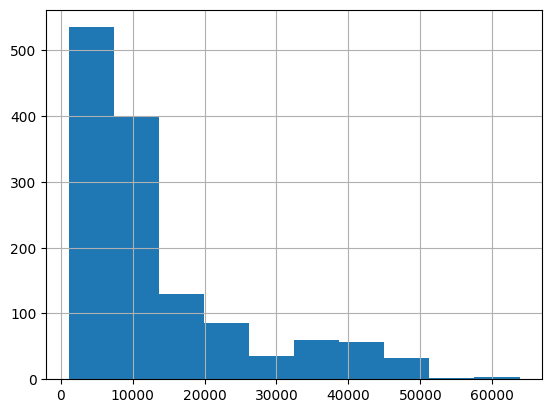

In [122]:
df['charges'].hist()

<Axes: >

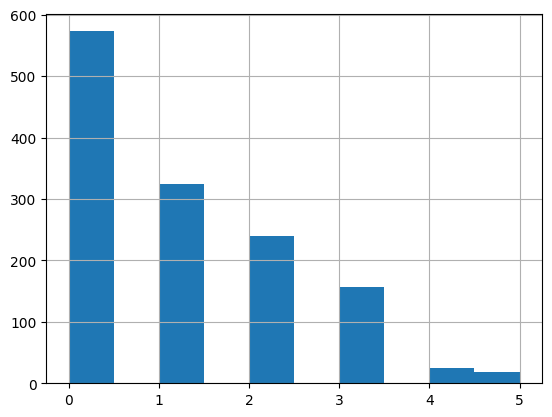

In [123]:
df['children'].hist()

###Категориальный

<Axes: >

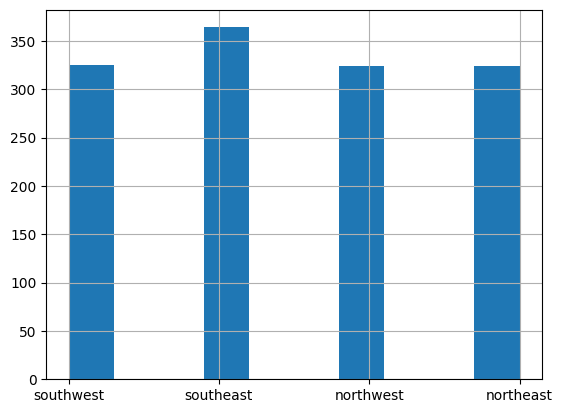

In [124]:
df['region'].hist()

<Axes: >

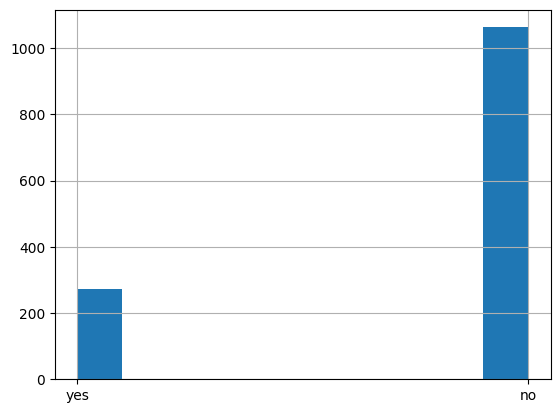

In [125]:
df['smoker'].hist()

<Axes: >

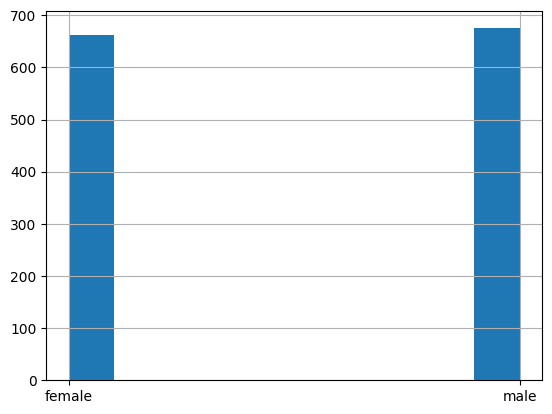

In [126]:
df['sex'].hist()

## Построение графиков взаимосвязи

### Визуализация взаимосвязи выплат и пола застрахованного лица

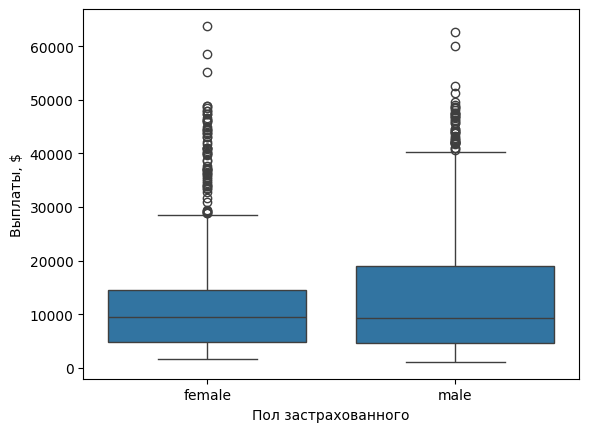

In [127]:
sns.boxplot(x='sex', y='charges', data=df)
plt.xlabel('Пол застрахованного')
plt.ylabel('Выплаты, $')
plt.show()

### Визуализация взаимосвязи выплат и курильщик

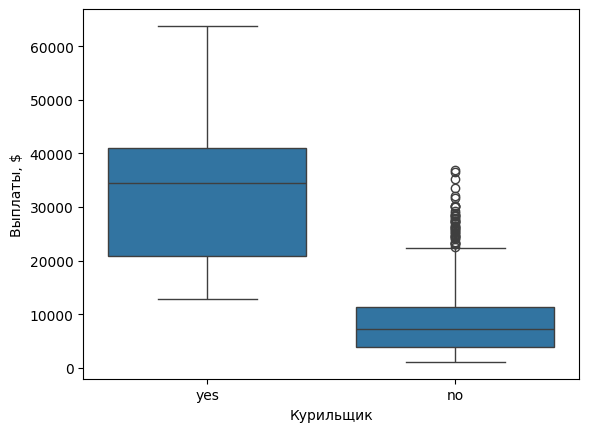

In [128]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.xlabel('Курильщик')
plt.ylabel('Выплаты, $')
plt.show()

### Визуализация взаимосвязи выплат и регионы

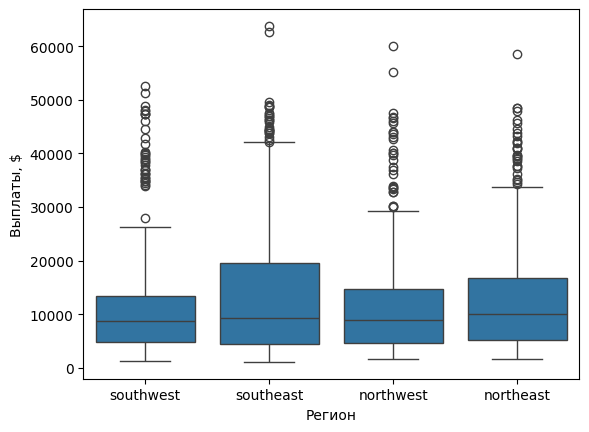

In [129]:
sns.boxplot(x='region', y='charges', data=df)
plt.xlabel('Регион')
plt.ylabel('Выплаты, $')
plt.show()

In [130]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


### Визуализация взаимосвязи выплат и индекса массы тела

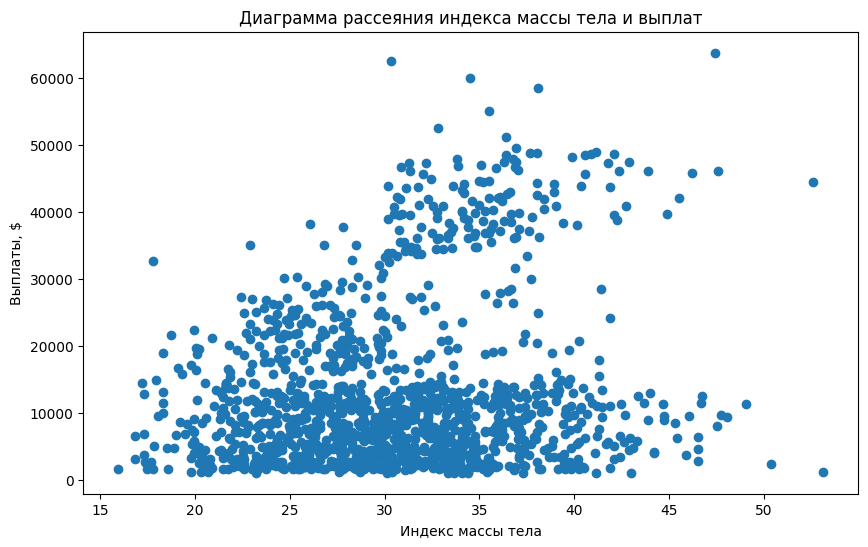

In [131]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x = df['bmi'], y = df['charges'])
plt.title('Диаграмма рассеяния индекса массы тела и выплат')
plt.xlabel('Индекс массы тела')
plt.ylabel('Выплаты, $')
plt.show()

### Визуализация взаимосвязи выплат и числа детей, охваченных мед.страховкой

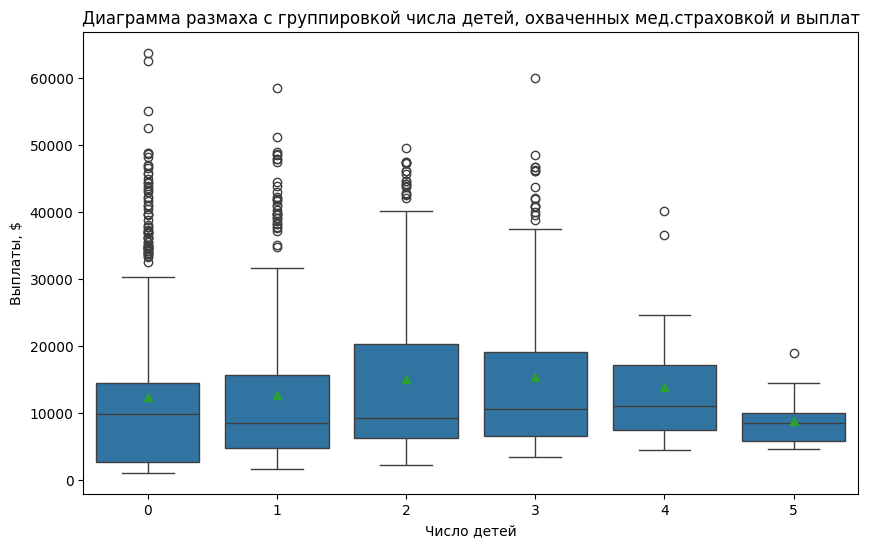

In [132]:
f, ax = plt.subplots(figsize=(10, 6))
fig = sns.boxplot(x='children', y='charges',data=df,showmeans=True)
plt.title('Диаграмма размаха с группировкой числа детей, охваченных мед.страховкой и выплат')
plt.xlabel('Число детей')
plt.ylabel('Выплаты, $')
plt.show()

###Визуализация взаимосвязи числа детей, охваченных мед.страховкой и регионы

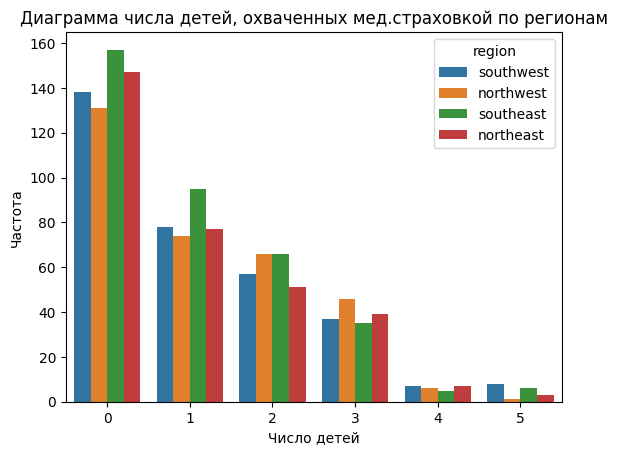

In [133]:
plt.title('Диаграмма числа детей, охваченных мед.страховкой по регионам')
sns.countplot(x=df['children'], hue=df['region'])
plt.ylabel('Частота')
plt.xlabel('Число детей')
plt.show()

###Визуализация взаимосвязи курильщика по регионам

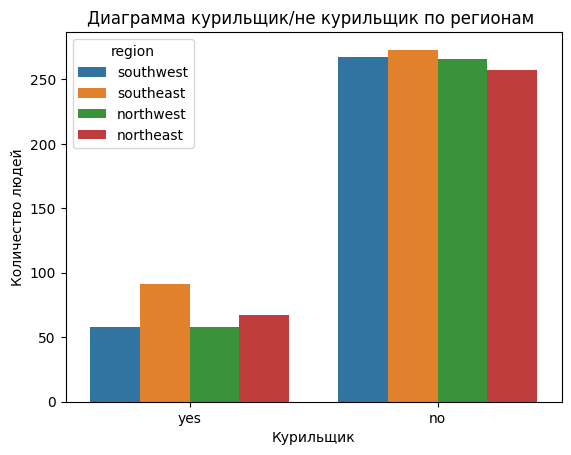

In [134]:

sns.countplot(x=df['smoker'], hue=df['region'])
plt.title('Диаграмма курильщик/не курильщик по регионам ')
plt.ylabel('Количество людей')
plt.xlabel('Курильщик')
plt.show()



###Визуализация взаимосвязи возраста и выплат

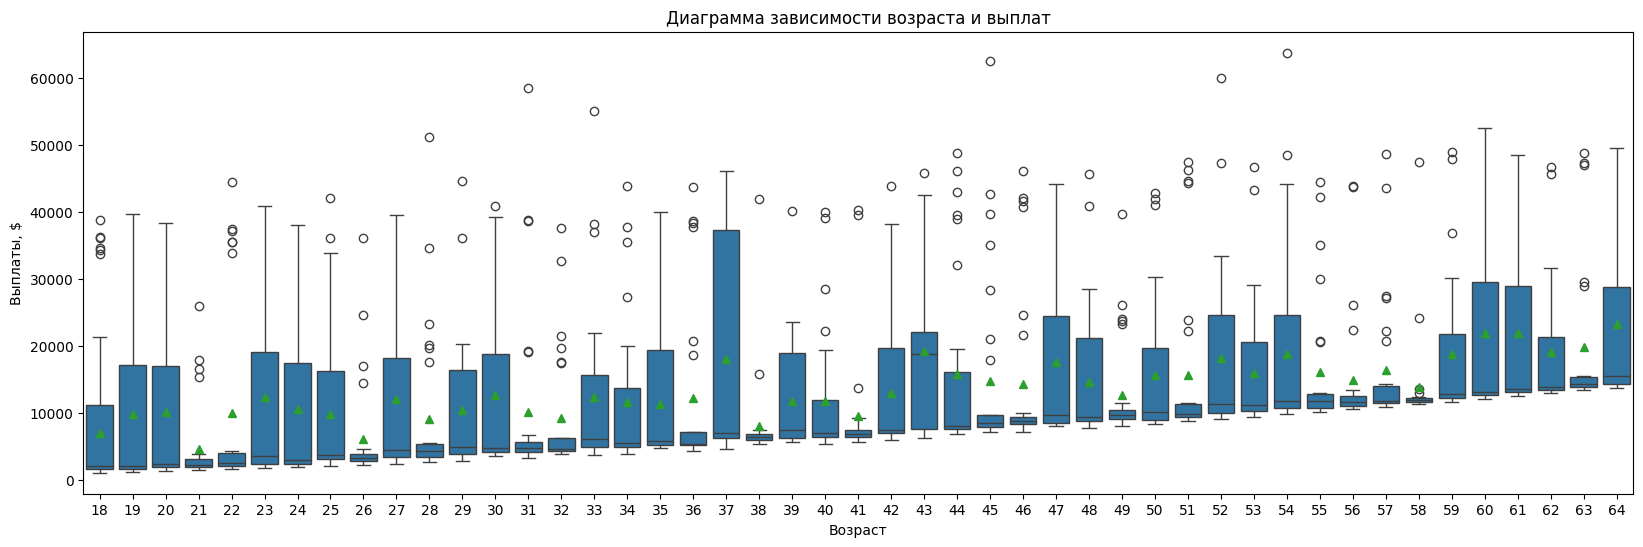

In [135]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(x = 'age', y = 'charges', data=df, showmeans=True)
plt.title('Диаграмма зависимости возраста и выплат')
plt.xlabel('Возраст')
plt.ylabel('Выплаты, $')
plt.show()

### Визуализация возраста и индекса массы тела

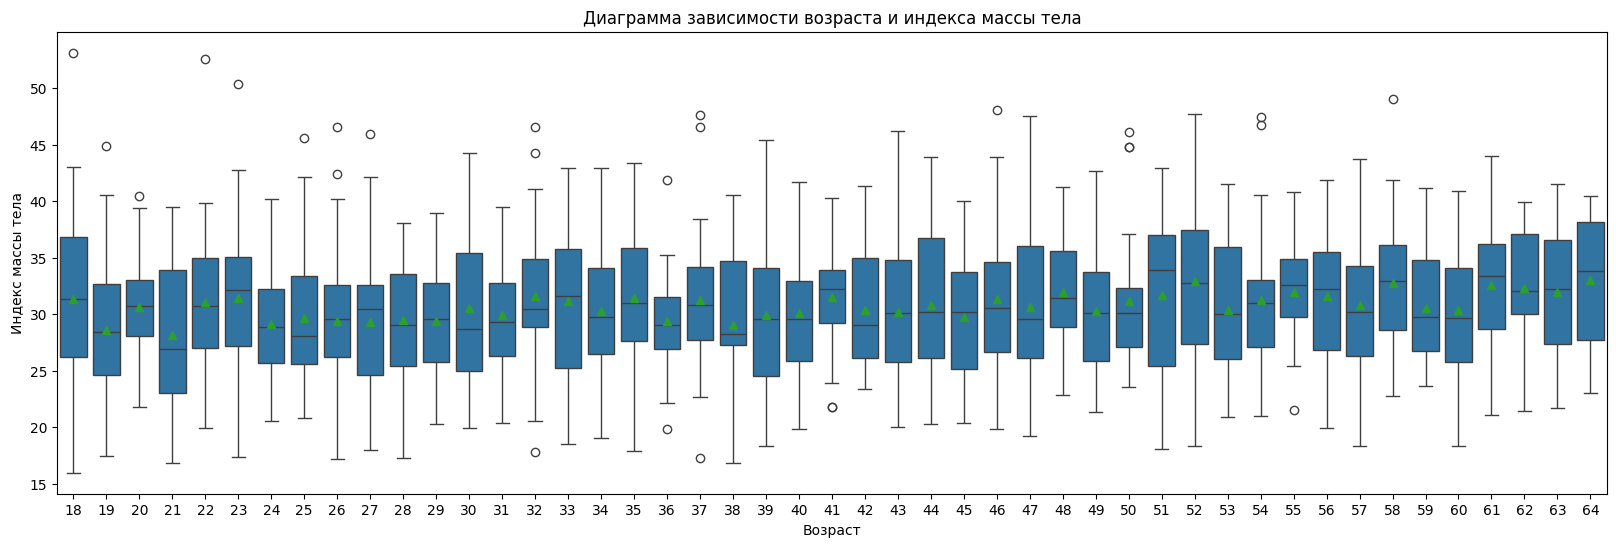

In [136]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(x = 'age', y = 'bmi', data=df, showmeans=True )
plt.title('Диаграмма зависимости возраста и индекса массы тела')
plt.xlabel('Возраст')
plt.ylabel('Индекс массы тела')
plt.show()

# Описательные статистики

In [137]:
df.drop(['sex','smoker','region'],axis=1).describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


## Проверка нормальности по критерию Шапиро-Уилка

In [138]:
# H0 - выборка соответствует нормальному закону распределения
# H1 - выборка не соответствует нормальному закону распределения
stats.shapiro(df['charges'])

ShapiroResult(statistic=np.float64(0.8147607893099357), pvalue=np.float64(1.1959741756687743e-36))

Размер индивидуальных мед.расходов - Выплат - НЕ соответствует нормальному закону распределения (p-value (= 1,2 * е-36) < a (= 0.05 ) уровня значимости, то отвергаем гипотезу H0 в пользу H1)

In [139]:
# H0 - выборка соответствует нормальному закону распределения
# H1 - выборка не соответствует нормальному закону распределения
stats.shapiro(df['bmi'])

ShapiroResult(statistic=np.float64(0.9938755131647968), pvalue=np.float64(2.575292856043621e-05))

Индекс массы тела - НЕ соответствует нормальному закону распределения (p-value (= 2.6 * е-05) < a (= 0.05) уровня значимости, то отвергаем гипотезу Н0 в пользу Н1)

# Сравнение групп

## Анализ влияния категориальных признаков на количественные показатели. Критерии сравнения групп

### Влияние на целевой показатель Размер индивидуальных мед.расходов - Выплат (charges)

#### Выплаты - Курильщик

In [140]:
# H0 - фактор Курильщик не оказывает влияния на Выплаты (или средние выплаты курильщикам и некуририльщикам равны)
# H1 - фактор Курильщик оказывает влияния на Выплаты
df.groupby('smoker')[['charges']].mean()

,charges
smoker,
no,8440.660307
yes,32050.231832


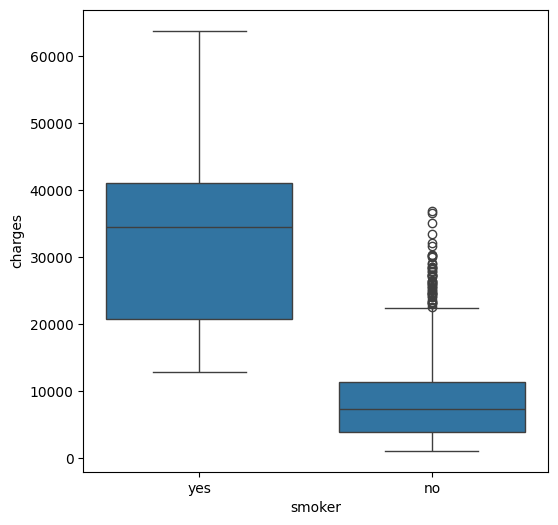

In [141]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='smoker', y='charges', data=df)

In [142]:
df_w0 = df[df['smoker']=='yes']
df_w1 = df[df['smoker']=='no']
print(stats.shapiro(df_w0['charges']))
print(stats.shapiro(df_w1['charges']))

ShapiroResult(statistic=np.float64(0.9395519386965634), pvalue=np.float64(3.6249900590074277e-09))
ShapiroResult(statistic=np.float64(0.872913393508985), pvalue=np.float64(1.5035032808411558e-28))



* H0 - выборка соответствует нормальному закону распределения
* H1 - выборка не соответствует нормальному закону распределения

если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии

In [143]:
scipy.stats.mannwhitneyu(df_w0['charges'],df_w1['charges'])

MannwhitneyuResult(statistic=np.float64(283859.0), pvalue=np.float64(5.74701188239214e-130))

p-value < a (= 0,05) уровня значимости, то отвергаем гипотезу H0 в пользу H1,
т.е. выборка НЕ соответствует нормальному закону распределения =>
фактор Курильщик оказывает влияние на Выплаты

#### Выплаты - Пол

In [144]:
# H0 - фактор Пол (sex) не оказывает влияния на Выплаты (или средние выплаты по каждому полу равны)
# H1 - фактор Пол (sex) влияет на Выплаты
df.groupby('sex')[['charges']].mean()

,charges
sex,
female,12569.578844
male,13974.998864


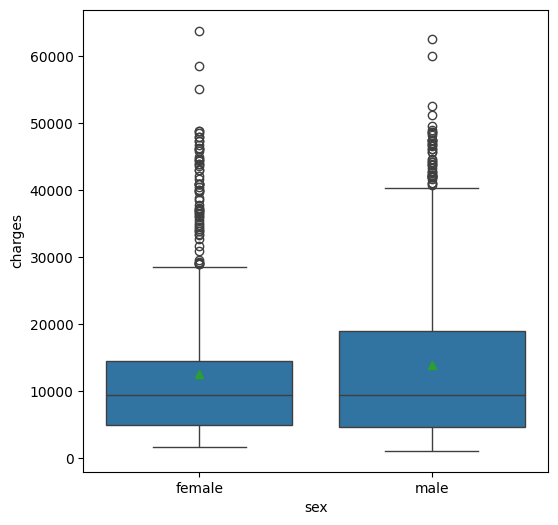

In [145]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='sex', y='charges', data=df, showmeans=True)

In [146]:
df_s0 = df[df['sex']=='male']
df_s1 = df[df['sex']=='female']
print(stats.shapiro(df_s0['charges']))
print(stats.shapiro(df_s1['charges']))

ShapiroResult(statistic=np.float64(0.8230361988228667), pvalue=np.float64(1.270698716763824e-26))
ShapiroResult(statistic=np.float64(0.8053936070521869), pvalue=np.float64(1.8303726201913448e-27))



* H0 - выборка соответствует нормальному закону распределения
* H1 - выборка не соответствует нормальному закону распределения

если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии

In [147]:
scipy.stats.mannwhitneyu(df_s0['charges'],df_s1['charges'])

MannwhitneyuResult(statistic=np.float64(226198.0), pvalue=np.float64(0.6944793894954917))

p-value > a (= 0,05) уровня значимости, то подтверждаем гипотезу H0,
=> фактор Пол не оказывает влияние на Выплаты

#### Выплаты - Регион

In [148]:
# H0 - фактор Регион не оказывает влияния на Выплаты (или средние выплаты в разных регионах равны)
# H1 - фактор Регион влияет на Выплаты
df.groupby('region')[['charges']].mean()

,charges
region,
northeast,13406.384516
northwest,12450.840844
southeast,14735.411438
southwest,12346.937377


In [149]:
#Количество выплат по регионам
df.groupby('region')[['charges']].count()

,charges
region,
northeast,324
northwest,324
southeast,364
southwest,325


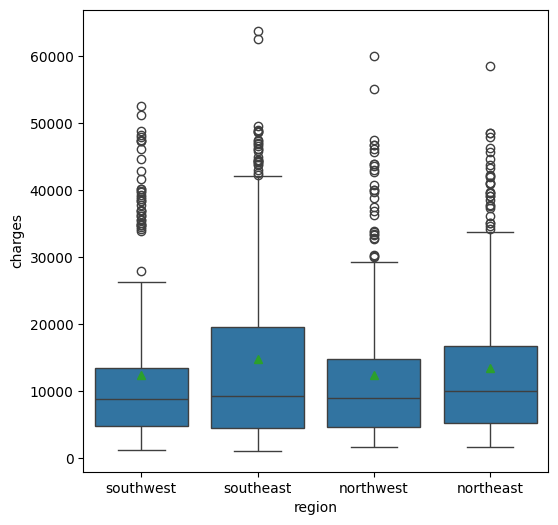

In [150]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='region', y='charges', data=df, showmeans=True)

##### Выплаты - Регион : Выбросы

In [151]:
# Регион : southwest
df.loc[(df['region'] == 'southwest')].describe()


,age,bmi,children,charges
count,325.000000,325.000000,325.000000,325.000000
mean,39.455385,30.596615,1.141538,12346.937377
std,13.959886,5.691836,1.275952,11557.179101
min,19.000000,17.400000,0.000000,1241.565000
25%,27.000000,26.900000,0.000000,4751.070000
50%,39.000000,30.300000,1.000000,8798.593000
75%,51.000000,34.600000,2.000000,13462.520000
max,64.000000,47.600000,5.000000,52590.829390


In [152]:
df.loc[(df['charges'] > 50000) & (df['region'] == 'southwest')] # обнаружение выброса

,age,sex,bmi,children,smoker,region,charges
34,28,male,36.4,1,yes,southwest,51194.55914
1145,60,male,32.8,0,yes,southwest,52590.82939


In [153]:
df=df.drop(df.index[[34]]) # удаление выброса
df=df.drop(df.index[[1145]]) # удаление выброса

In [154]:
# Регион : southeast
df.loc[(df['region'] == 'southeast')].describe()

,age,bmi,children,charges
count,364.000000,364.000000,364.000000,364.000000
mean,38.939560,33.355989,1.049451,14735.411438
std,14.164585,6.477648,1.177276,13971.098589
min,18.000000,19.800000,0.000000,1121.873900
25%,26.750000,28.572500,0.000000,4440.886200
50%,39.000000,33.330000,1.000000,9294.131950
75%,51.000000,37.812500,2.000000,19526.286900
max,64.000000,53.130000,5.000000,63770.428010


In [155]:
df.loc[(df['charges'] > 50000) & (df['region'] == 'southeast')] # обнаружение выброса

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.41,0,yes,southeast,63770.42801
1299,45,male,30.36,0,yes,southeast,62592.87309


In [156]:
df=df.drop(df.index[[54]]) # удаление выброса
df=df.drop(df.index[[1299]]) # удаление выброса

In [157]:
#Регион : northwest
df.loc[(df['region'] == 'northwest')].describe()

,age,bmi,children,charges
count,322.000000,322.000000,322.000000,322.000000
mean,39.260870,29.162935,1.152174,12373.647112
std,13.991774,5.139568,1.172828,10918.905346
min,19.000000,17.385000,0.000000,1621.340200
25%,26.250000,25.745000,0.000000,4773.196413
50%,39.000000,28.880000,1.000000,8976.977250
75%,51.000000,32.751250,2.000000,14706.975188
max,64.000000,42.940000,5.000000,60021.398970


In [158]:
df.loc[(df['charges'] > 50000) & (df['region'] == 'northwest')] # обнаружение выброса

,age,sex,bmi,children,smoker,region,charges
818,33,female,35.530,0,yes,northwest,55135.40209
1229,52,male,34.485,3,yes,northwest,60021.39897


In [159]:
df=df.drop(df.index[[818]]) # удаление выброса
df=df.drop(df.index[[1229]]) # удаление выброса

In [160]:
#Регион : northeast
df.loc[(df['region'] == 'northeast')].describe()

,age,bmi,children,charges
count,324.000000,324.000000,324.000000,324.000000
mean,39.268519,29.173503,1.046296,13406.384516
std,14.069007,5.937513,1.198949,11255.803066
min,18.000000,15.960000,0.000000,1694.796400
25%,27.000000,24.866250,0.000000,5194.322288
50%,39.500000,28.880000,1.000000,10057.652025
75%,51.000000,32.893750,2.000000,16687.364100
max,64.000000,48.070000,5.000000,58571.074480


In [161]:
df.loc[(df['charges'] > 50000) & (df['region'] == 'northeast')] # обнаружение выброса

,age,sex,bmi,children,smoker,region,charges
577,31,female,38.095,1,yes,northeast,58571.07448


In [162]:
df=df.drop(df.index[[577]]) # удаление выброса

##### Выплаты - Регион : Расчет

In [163]:
df_r1=np.array(df[df['region']=='southwest']['charges'])
df_r2=np.array(df[df['region']=='southeast']['charges'])
df_r3=np.array(df[df['region']=='northwest']['charges'])
df_r4=np.array(df[df['region']=='northeast']['charges'])

In [164]:
print(stats.shapiro(df_r1))
print(stats.shapiro(df_r2))
print(stats.shapiro(df_r3))
print(stats.shapiro(df_r4))

ShapiroResult(statistic=np.float64(0.7849941835839551), pvalue=np.float64(2.511640870757376e-20))
ShapiroResult(statistic=np.float64(0.8247050093509753), pvalue=np.float64(1.3922626065525768e-19))
ShapiroResult(statistic=np.float64(0.8157050909589866), pvalue=np.float64(7.8294947422193835e-19))
ShapiroResult(statistic=np.float64(0.8358957554761356), pvalue=np.float64(7.502830843905826e-18))



* H0 - выборка соответствует нормальному закону распределения
* H1 - выборка не соответствует нормальному закону распределения

если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии

In [165]:
stats.mstats.kruskalwallis(df_r1,df_r2,df_r3,df_r4)

KruskalResult(statistic=np.float64(5.3287001759072155), pvalue=np.float64(0.14925088376017323))

p-value > a (= 0,05) уровня значимости, то подтверждаем гипотезу H0,
=> фактор Регион не оказывает влияние на Выплаты

### Влияние категориальных признаков на показатель Индекс массы тела (bmi)

#### Индекс массы тела - Курильщик

In [166]:
# H0 - фактор Курильщик не оказывает влияния на Индекс массы тела (или средний индекс массы тела для курильщика и не курильщика равны)
# H1 - фактор Курильщик оказывает влияния на Индекс массы тела
df.groupby('smoker')[['bmi']].mean()

,bmi
smoker,
no,30.672365
yes,30.675129


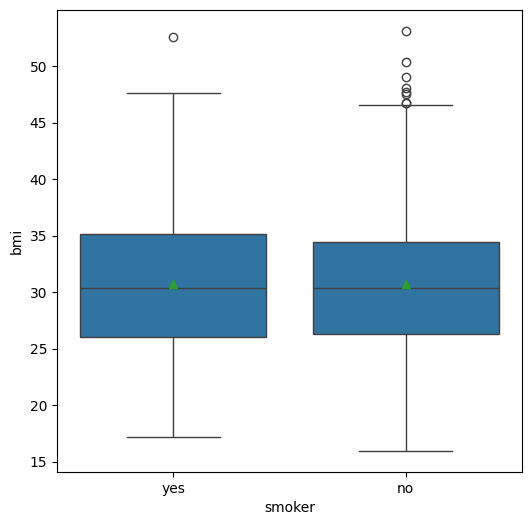

In [167]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='smoker', y='bmi', data=df, showmeans=True)

In [168]:
df_sm0 = df[df['smoker']=='yes']
df_sm1 = df[df['smoker']=='no']
print(stats.shapiro(df_sm0['bmi']))
print(stats.shapiro(df_sm1['bmi']))

ShapiroResult(statistic=np.float64(0.9907088292874251), pvalue=np.float64(0.08304297142832967))
ShapiroResult(statistic=np.float64(0.9941525844550478), pvalue=np.float64(0.00037716306702866893))


* H0 - выборка соответствует нормальному закону распределения
* H1 - выборка не соответствует нормальному закону распределения

если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии

In [169]:

scipy.stats.mannwhitneyu(df_sm0['bmi'],df_sm1['bmi'])

MannwhitneyuResult(statistic=np.float64(143169.0), pvalue=np.float64(0.9540638737010622))

 так как p-value > a (=0.05) уровня значимости, то подтверждаем гипотезу H0
 => фактор Курильщик не оказывает влияние на индекс массы тела

#### Индекс массы тела - Пол

In [170]:
# H0 - фактор Пол (sex) не оказывает влияния на Индекс массы тела (или средние индексы для каждого пола равны)
# H1 - фактор Пол (sex) влияет на Индекс массы тела
df.groupby('sex')[['bmi']].mean()

,bmi
sex,
female,30.389765
male,30.951028


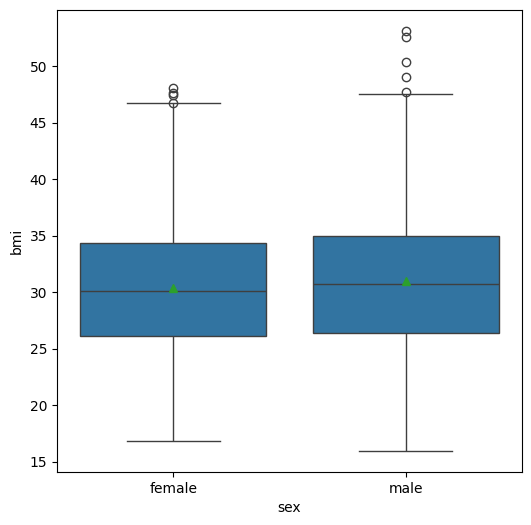

In [171]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='sex', y='bmi', data=df, showmeans=True)

In [172]:
df_si0 = df[df['sex']=='male']
df_si1 = df[df['sex']=='female']
print(stats.shapiro(df_si0['bmi']))
print(stats.shapiro(df_si1['bmi']))

ShapiroResult(statistic=np.float64(0.9926119233678196), pvalue=np.float64(0.002088350039072944))
ShapiroResult(statistic=np.float64(0.9931083608265561), pvalue=np.float64(0.003986579819984176))


* H0 - выборка соответствует нормальному закону распределения
* H1 - выборка не соответствует нормальному закону распределения
если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии

In [173]:
scipy.stats.mannwhitneyu(df_si0['bmi'],df_si1['bmi'])

MannwhitneyuResult(statistic=np.float64(232282.5), pvalue=np.float64(0.11016092084085341))

 так как p-value > a (=0.05) уровня значимости, то подтверждаем гипотезу H0
 => фактор Пол не оказывает влияние на Индекс массы тела

#### Индекс массы тела - Регион

In [174]:
# H0 - фактор Регион не оказывает влияния на Индекс массы тела (или средние индексы в разных регионах равны)
# H1 - фактор Регион влияет на Индекс массы тела
df.groupby('region')[['bmi']].mean()

,bmi
region,
northeast,29.191176
northwest,29.198738
southeast,33.371212
southwest,30.587307


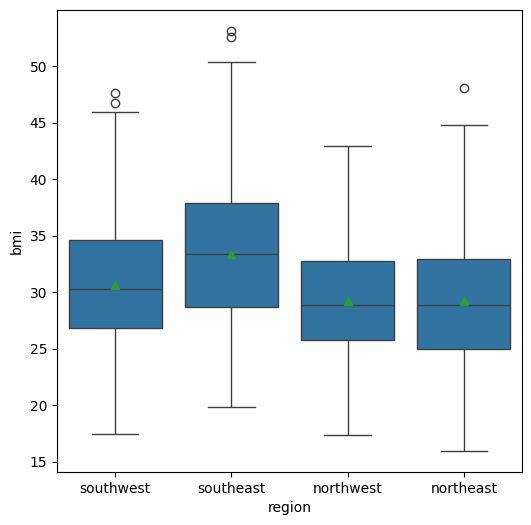

In [175]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='region', y='bmi', data=df, showmeans=True)

In [176]:
df_ir1=np.array(df[df['region']=='southwest']['bmi'])
df_ir2=np.array(df[df['region']=='southeast']['bmi'])
df_ir3=np.array(df[df['region']=='northwest']['bmi'])
df_ir4=np.array(df[df['region']=='northeast']['bmi'])

In [177]:
print(stats.shapiro(df_ir1))
print(stats.shapiro(df_ir2))
print(stats.shapiro(df_ir3))
print(stats.shapiro(df_ir4))

ShapiroResult(statistic=np.float64(0.9949211527017954), pvalue=np.float64(0.3668531453402363))
ShapiroResult(statistic=np.float64(0.9911721473481411), pvalue=np.float64(0.028854674819661585))
ShapiroResult(statistic=np.float64(0.9955665224832568), pvalue=np.float64(0.497183948718818))
ShapiroResult(statistic=np.float64(0.9922610629311748), pvalue=np.float64(0.09137149160088039))


H0 - выборка соответствует нормальному закону распределения
H1 - выборка не соответствует нормальному закону распределения
если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии


In [178]:
stats.mstats.kruskalwallis(df_ir1,df_ir2,df_ir3,df_ir4 )

KruskalResult(statistic=np.float64(94.92462703308564), pvalue=np.float64(1.9165211134441057e-20))

так как p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу Н1 => фактор Регион влияет на Индекс массы тела

### Влияние категориальных признаков на показатель Возраст (age)

#### Возраст - Курильщик

In [179]:
# H0 - фактор Курильщик не оказывает влияния на возраст (или средний возраст для курильщика и не курильщика равны)
# H1 - фактор Курильщик оказывает влияние на возраст
df.groupby('smoker')[['age']].mean()

,age
smoker,
no,39.443815
yes,38.464945


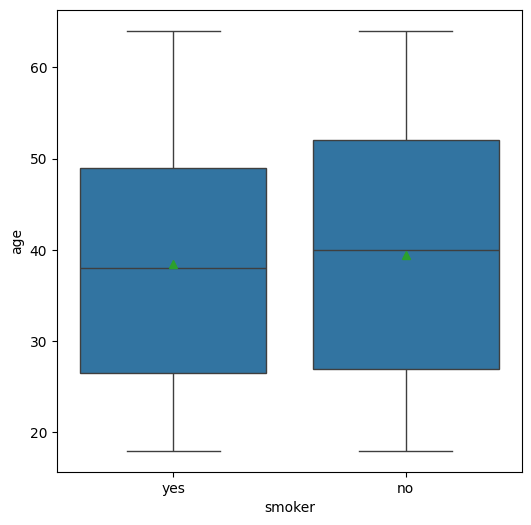

In [180]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='smoker', y='age', data=df, showmeans=True)

In [181]:
df_sa0 = df[df['smoker']=='yes']
df_sa1 = df[df['smoker']=='no']
print(stats.shapiro(df_sa0['age']))
print(stats.shapiro(df_sa1['age']))

ShapiroResult(statistic=np.float64(0.9478728216200172), pvalue=np.float64(3.093824243823156e-08))
ShapiroResult(statistic=np.float64(0.9432557706414727), pvalue=np.float64(1.0307263871213796e-19))


H0 - выборка соответствует нормальному закону распределения
H1 - выборка не соответствует нормальному закону распределения если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии

In [182]:
scipy.stats.mannwhitneyu(df_sa0['age'],df_sa1['age'])

MannwhitneyuResult(statistic=np.float64(137674.0), pvalue=np.float64(0.30212894138818214))

так как p-value > a (=0.05) уровня значимости, то подтверждаем гипотезу H0
 => фактор Курильщик не оказывает влияния на возраст

#### Возраст - Регион

In [183]:
# H0 - фактор Регион не оказывает влияния на возраст (или средний возраст для регионов равны)
# H1 - фактор Регион оказывает влияния на возраст
df.groupby('region')[['age']].mean()

,age
region,
northeast,39.312693
northwest,39.302181
southeast,38.922865
southwest,39.479876


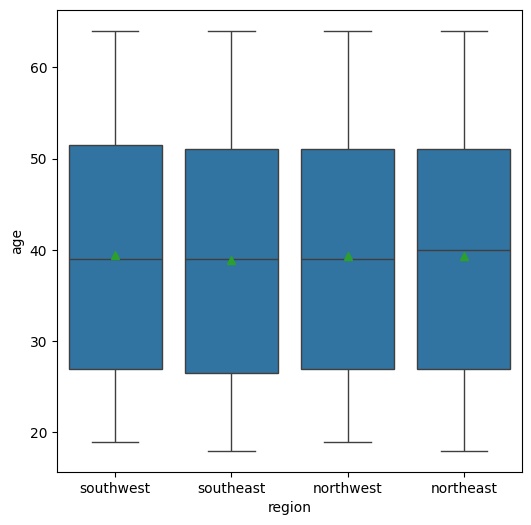

In [184]:
f, ax = plt.subplots(figsize=(6, 6))
fig = sns.boxplot(x='region', y='age', data=df, showmeans=True)

In [185]:
df_ra1=np.array(df[df['region']=='southwest']['age'])
df_ra2=np.array(df[df['region']=='southeast']['age'])
df_ra3=np.array(df[df['region']=='northwest']['age'])
df_ra4=np.array(df[df['region']=='northeast']['age'])

In [186]:
print(stats.shapiro(df_ra1))
print(stats.shapiro(df_ra2))
print(stats.shapiro(df_ra3))
print(stats.shapiro(df_ra4))

ShapiroResult(statistic=np.float64(0.9401781099599695), pvalue=np.float64(3.8757158479691373e-10))
ShapiroResult(statistic=np.float64(0.944756896694957), pvalue=np.float64(2.164062592056827e-10))
ShapiroResult(statistic=np.float64(0.9403913108509167), pvalue=np.float64(4.485835034895359e-10))
ShapiroResult(statistic=np.float64(0.9447619181136043), pvalue=np.float64(1.244742110698763e-09))



* H0 - выборка соответствует нормальному закону распределения
* H1 - выборка не соответствует нормальному закону распределения

если p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1, иначе наоборот если хотя бы для 1 выборки отвергается гипотеза H0, то используем непараметрические критерии

In [187]:
stats.mstats.kruskalwallis(df_ra1,df_ra2,df_ra3,df_ra4)

KruskalResult(statistic=np.float64(0.4938833154240877), pvalue=np.float64(0.9202331509721586))

p-value > a (= 0,05) уровня значимости, то подтверждаем гипотезу H0,
=> фактор Регион не оказывает влияние на Возраст

# Корреляционный анализ

## Анализ связи количественных и порядковых признаков

In [188]:
# Связь Выплат - Индекса массы тела - Возраста
df[['charges','bmi','age']].corr(method='pearson') # количественная корреляция Пирсона

,charges,bmi,age
charges,1.000000,0.194999,0.298340
bmi,0.194999,1.000000,0.107521
age,0.298340,0.107521,1.000000


In [189]:
# Связь Выплат - Индекса массы тела - Возраста - Число застрахованных детей
df[['charges','bmi','age','children']].corr(method='spearman') # ранговая корреляция Спирмена

,charges,bmi,age,children
charges,1.000000,0.115507,0.532691,0.129409
bmi,0.115507,1.000000,0.106435,0.012485
age,0.532691,0.106435,1.000000,0.052159
children,0.129409,0.012485,0.052159,1.000000


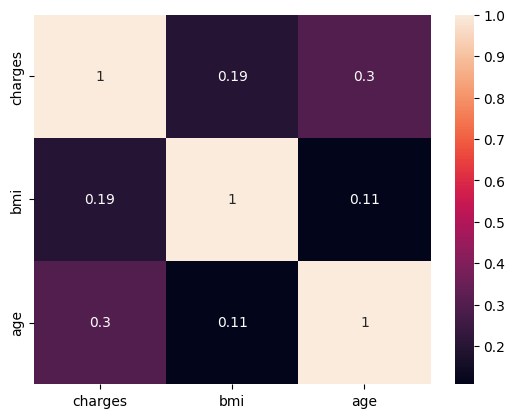

In [190]:
num = ['charges','bmi','age']
hm = sns.heatmap(df[num].corr(),annot=True)

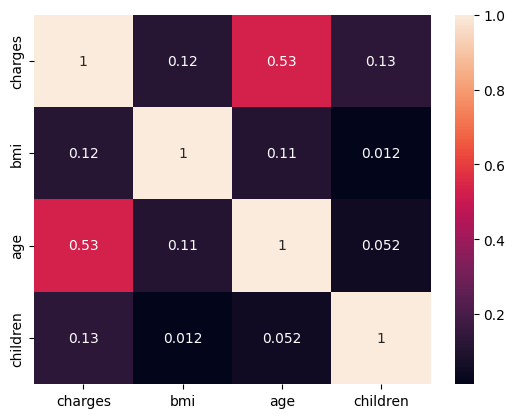

In [191]:
ran = ['charges','bmi','age','children']
hm = sns.heatmap(df[ran].corr(method = 'spearman'), annot=True)

### Значимость факторов по коэффициенту корреляции Пирсона

In [192]:
# H0 - коэффициент корреляции для пары факторов не значим (или коэффициент корреляции = 0)
# H1 - корреляционная связь 2-х факторов значима
# так как p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу H1

columns = ['charges','bmi','age','children']
for i in range(len(columns)):
  for j in range(i+1,len(columns)):
    pvalue = scipy.stats.pearsonr(df[columns[i]],df[columns[j]])[1]
    pvalue_float = float("{:.2f}".format(pvalue))
    if pvalue_float < 0.05:
      print(f'{columns[i]} - {columns[j]} : H1 - значимая корреляционная связь')

charges - bmi : H1 - значимая корреляционная связь
charges - age : H1 - значимая корреляционная связь
charges - children : H1 - значимая корреляционная связь
bmi - age : H1 - значимая корреляционная связь


### Значимость факторов по ранговой корреляции Спирмена

In [193]:
columns = ['charges','bmi','age','children', 'region', 'sex','smoker']
for i in range(len(columns)):
  for j in range(i+1,len(columns)):
    pvalue = scipy.stats.spearmanr(df[columns[i]],df[columns[j]])[1]
    pvalue_float = float("{:.2f}".format(pvalue))
    if pvalue_float >= 0.05:
      print(f'{columns[i]} - {columns[j]} : H0 - не значимая корреляционная связь')


charges - region : H0 - не значимая корреляционная связь
charges - sex : H0 - не значимая корреляционная связь
bmi - children : H0 - не значимая корреляционная связь
bmi - sex : H0 - не значимая корреляционная связь
bmi - smoker : H0 - не значимая корреляционная связь
age - children : H0 - не значимая корреляционная связь
age - region : H0 - не значимая корреляционная связь
age - sex : H0 - не значимая корреляционная связь
age - smoker : H0 - не значимая корреляционная связь
children - region : H0 - не значимая корреляционная связь
children - sex : H0 - не значимая корреляционная связь
children - smoker : H0 - не значимая корреляционная связь
region - sex : H0 - не значимая корреляционная связь
region - smoker : H0 - не значимая корреляционная связь


## Связь категориальных признаков

### Курильщик - Пол

In [194]:
# H0 - связь между факторами Курильщик и Пол отсутствует
# H1 - связь между факторами Курильщик и Пол есть
S=pd.crosstab(df['smoker'],df['sex'])
S

sex,female,male
smoker,,
no,544,515
yes,115,156


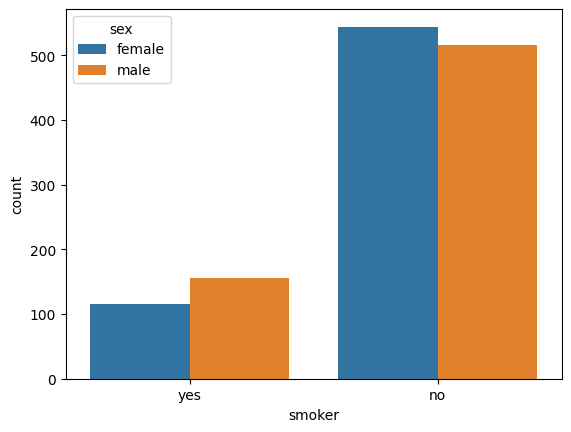

In [195]:
sns.countplot(x=df['smoker'], hue=df['sex']);

In [196]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(S)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 6.536641546766029
degrees of freedom: 1
p-value: 0.010567466318410925



p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу Н1
=> связь между факторами Курильщик и Пол есть

### Курильщик - Регион

In [197]:
# H0 - связь между факторами Курильщик и Регион отсутствует
# H1 - связь между факторами Курильщик и Регион есть
SR=pd.crosstab(df['smoker'],df['region'])
SR

region,northeast,northwest,southeast,southwest
smoker,,,,
no,256,264,272,267
yes,67,57,91,56


<Axes: xlabel='region', ylabel='count'>

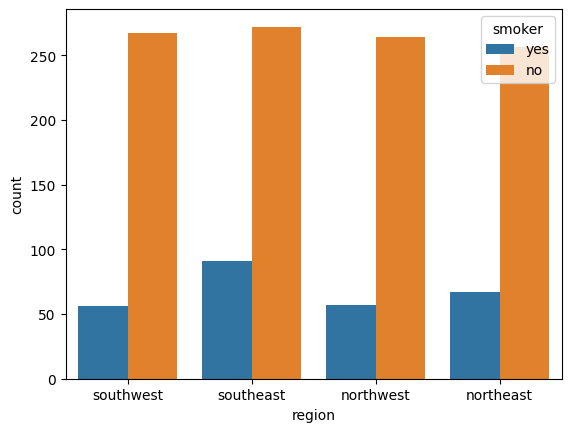

In [198]:
sns.countplot(x=df['region'], hue=df['smoker'])

In [199]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(SR)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 8.149466119183812
degrees of freedom: 3
p-value: 0.043021607951154915



p-value < a (=0.05) уровня значимости, то отвергаем гипотезу H0 в пользу Н1
=> связь между факторами Курильщик и Регион есть

### Пол - Регион

In [200]:
# H0 - связь между факторами Пол и Регион города отсутствует
# H1 - связь между факторами Пол и Регион города есть
SR=pd.crosstab(df['sex'],df['region'])
SR

region,northeast,northwest,southeast,southwest
sex,,,,
female,160,163,174,162
male,163,158,189,161


<Axes: xlabel='region', ylabel='count'>

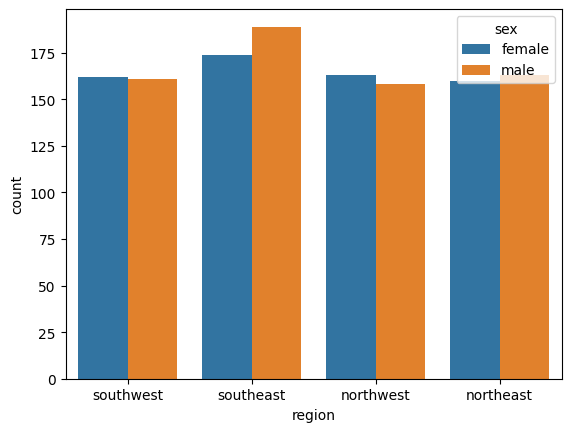

In [201]:
sns.countplot(x=df['region'], hue=df['sex'])

In [202]:
chi2, prob, f, expected = scipy.stats.chi2_contingency(SR)
output = "test Statistics: {}\ndegrees of freedom: {}\np-value: {}\n"

print(output.format( chi2, f, prob))

test Statistics: 0.6204559154710161
degrees of freedom: 3
p-value: 0.8917339047933248



p-value >= a (=0.05) уровня значимости, то нет оснований отвергнуть гипотезу H0
=> связь между факторами Пол и Регион отсутствует

# Регрессионный анализ

## Парная регресия

Предобработка данных для регрессионного анализа (сделано сейчас, поскольку в предыдущих графиках были бы не ясны некоторые значения)


In [203]:
df['smoker'] = df['smoker'].map(lambda x: 1 if x == 'yes' else 0)
df['sex'] = df['sex'].map(lambda k: 1 if k == 'male' else 0)
df['region'] = df['region'].map(lambda r: 1 if r == 'southeast' else 2 if r == 'southwest' else 3 if r == 'northwest' else 4 )


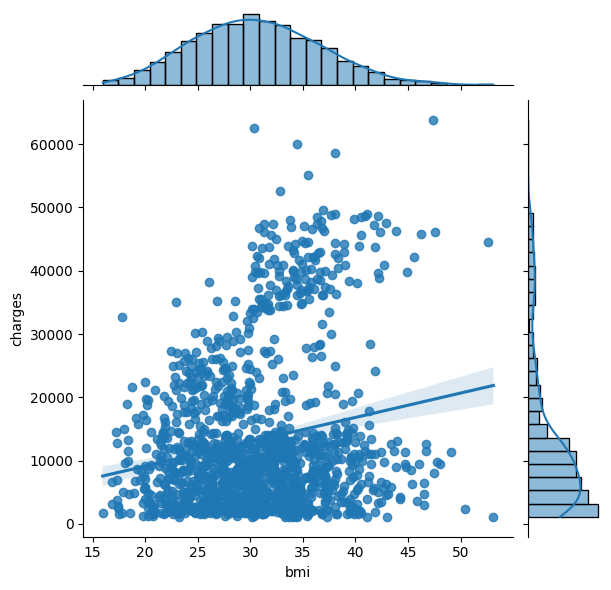

In [204]:
#sns.set(style="darkgrid")
sns.jointplot(x='bmi', y='charges', data=df, kind="reg")

Вывод из графика: с повышением среднего значения Индекса массы тела показатели средних Выплат растут не явно, находясь а пределах выплат от 0 до 20 000

In [206]:
# Построение линейной регрессии
LR = lm.LinearRegression()

In [207]:
# Однофакторная модель
one_f_mod = LR.fit(df[['bmi']],df[['charges']])

In [208]:
# intercept - оценка параметра а

one_f_mod.intercept_, one_f_mod.coef_

#394.76 факторный коэффициент, который будет умножаться на индекс массы тела при формировании выплат

(array([1432.02266887]), array([[384.7631243]]))

In [209]:
# коэффицент детерминации (метрика качества)
r2 = one_f_mod.score(df[['bmi']],df[['charges']])
r2
# r2 = 4%
# на 4% включенный фактор Индекс массы тела описывает вариативность целевого показателя Выплаты

0.038024476897061454

## Парная регрессия (OLS). Статистический подход.

In [210]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [211]:
# OLS - метод наименьших квадратов
res_ols_charges_bmi = smf.ols('charges ~ bmi', data=df).fit()
res_ols_charges_bmi.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     52.49
Date:                Fri, 03 Oct 2025   Prob (F-statistic):           7.30e-13
Time:                        11:18:31   Log-Likelihood:                -14357.
No. Observations:                1330   AIC:                         2.872e+04
Df Residuals:                    1328   BIC:                         2.873e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1432.0227   1660.770      0.862      0.389   -1825.995    4690.041
bmi          384.7631     53.106      7.245      0.000     280.582     488.944
==============================================================================
Omnibus:                      262.429   Durbin-Watson:                   1.978
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              436.202
Skew:                           1.304   Prob(JB):                     1.91e-95
Kurtosis:                       4.037   Cond. No.                         161.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

* Статистика Фишера об общей неадекватности модели : F-statistic:	52.49
* Значение p-value: Prob (F-statistic):	7.30e-13, это значение много меньше уровня значимости а (-0,05), значит гипотеза о неадекватности модели отклоняется, модель адекватна;
* среднеквадратическое отклонение для каждого коэффициента составляет 1660.770 и 53.106 соответственно;
* P>|t| : коэфициент Выплаты 0,389 > 0,05 гипотеза о незначимости данного коэфициэнта подтверждается; коэфициент Индекс массы тела 0,00 < 0.05 гипотеза о незначимости данного коэфициента отклоняется;
* Доверительные интервалы: для Выплат в диапазоне -1825 : 4690; для Индекса массы тела в диапазоне 280 : 488;
* Durbin-Watson:	1.979 близка к 2, т.е. корреляции в последовательности наблюдений НЕТ;
* Нормальность остатков: коэф.ассимитрии Skew:	1.304; коэф.эксцесса Kurtosis:	4.037; p-value - Prob(JB):	1.91e-95  < 0.05, соответственно отклоняем гипотезу о нормальности закона распределения остатков.


## МНОЖЕСТВЕННАЯ РЕГРЕССИЯ

In [212]:
data_x=df[['bmi','smoker','sex','children']]
data_x

,bmi,smoker,sex,children
0,27.900,1,0,0
1,33.770,0,1,1
2,33.000,0,1,3
3,22.705,0,1,0
...,...,...,...,...
1333,31.920,0,0,0
1334,36.850,0,0,0
1335,25.800,0,0,0
1336,29.070,1,0,0


In [213]:
data_y=df[['charges']]

In [214]:
mod_m = LR.fit(data_x,data_y)

In [215]:
mod_m.intercept_, mod_m.coef_

(array([-3814.63127053]),
 array([[  384.64353848, 23462.8922476 ,  -356.68859958,   591.65924217]]))

In [216]:
# коэффицент детерминации (метрика качества)
r2 = mod_m.score(data_x,data_y)
r2

0.6582209188380433

 Коэф.детерминации: значение r2 увеличилось с 4% (при парной регресии основного признака Выплаты и фактора Индекс массы тела) до 66% (при множественной регрессии основного признака Выплаты и группы факторов Индекс массы тела, Курильщик, Пол, Дети), т.к. уменьшился объём остаточной дисперсии.



---



Прогнозные данные для нового наблюдения: ['bmi','smoker','sex','children']
* Индекс массы тела = 25
* Курильщик = 0 (нет)
* Пол = 0 (male - мужской)
* Дети = 1

In [217]:
data_x_new = [[25,0,0,1]]

In [218]:
data_y_new=mod_m.predict(data_x_new)
print("Прогноз выплаты: ", data_y_new.round(2))

Прогноз выплаты:  [[6393.12]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Выплаты с признаками нового наблюдения составят: 6393,12

### Множественная регрессия (OLS)

In [219]:
resultsm = smf.ols('charges ~ bmi + smoker + sex + children' , data=df).fit()
resultsm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     637.9
Date:                Fri, 03 Oct 2025   Prob (F-statistic):          5.58e-307
Time:                        11:22:10   Log-Likelihood:                -13668.
No. Observations:                1330   AIC:                         2.735e+04
Df Residuals:                    1325   BIC:                         2.737e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3814.6313   1019.231     -3.743      0.000   -5814.114   -1815.148
bmi          384.6435     31.725     12.124      0.000     322.406     446.881
smoker      2.346e+04    480.796     48.800      0.000    2.25e+04    2.44e+04
sex         -356.6886    387.798     -0.920      0.358   -1117.454     404.077
children     591.6592    160.160      3.694      0.000     277.465     905.853
==============================================================================
Omnibus:                      162.051   Durbin-Watson:                   2.035
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              255.334
Skew:                           0.840   Prob(JB):                     3.59e-56
Kurtosis:                       4.336   Cond. No.                         166.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

* Статистика Фишера об общей неадекватности модели : F-statistic:	637.9;
* Значение p-value: Prob (F-statistic):	5,58e-307, это значение много меньше уровня значимости а (-0,05), значит гипотеза о неадекватности модели отклоняется, модель адекватна;
* Значение коэфицентов coef: Пол (sex) = -356, много меньше 0, но при этом p-value (0,426) > 0.05 (коэфицента значимости), исходя из чего делаем вывод что этот коэфицент в модели совсем не нужен, его можно исключить;
* P>|t| : коэфициент Выплаты 0,000 < 0,05 гипотеза о незначимости данного коэфициэнта отклоняется; коэфициент Индекс массы тела 0,00 < 0.05 гипотеза о незначимости данного коэфициента отклоняется; коэфициент Курильщик 0,00 < 0.05 гипотеза о незначимости данного коэфициента отклоняется; коэфициент Дети 0,00 < 0.05 гипотеза о незначимости данного коэфициента отклоняется;
* Durbin-Watson:	2.035 принмает значение 2, т.е. корреляции в последовательности наблюдений НЕТ.
* Нормальность остатков: коэф.ассимитрии Skew:	0.840; коэф.эксцесса Kurtosis:	4.336; p-value - Prob(JB):	3.59e-56  < 0.05, соответственно отклоняем гипотезу о нормальности закона распределения остатков
---
На основании вышеизложенного исключим из расчета фактор Пол (sex) и построим множественну модель регрессии.

In [220]:
resultsm = smf.ols('charges ~ bmi + smoker + children' , data=df).fit()
resultsm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     850.4
Date:                Fri, 03 Oct 2025   Prob (F-statistic):          2.69e-308
Time:                        11:24:28   Log-Likelihood:                -13669.
No. Observations:                1330   AIC:                         2.735e+04
Df Residuals:                    1326   BIC:                         2.737e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3944.1896   1009.392     -3.907      0.000   -5924.370   -1964.009
bmi          383.3018     31.690     12.095      0.000     321.134     445.470
smoker      2.343e+04    479.522     48.863      0.000    2.25e+04    2.44e+04
children     589.1454    160.127      3.679      0.000     275.016     903.275
==============================================================================
Omnibus:                      162.538   Durbin-Watson:                   2.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              256.460
Skew:                           0.841   Prob(JB):                     2.04e-56
Kurtosis:                       4.340   Cond. No.                         164.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

* Статистика Фишера об общей неадекватности модели : F-statistic:	850.4;
* Значение p-value: Prob (F-statistic):	2.69e-308, это значение много меньше уровня значимости а (-0,05), значит гипотеза о неадекватности модели отклоняется, модель адекватна;
* Значение коэфицентов coef: целевой коэфицент меньше нуля, это указывает на то, что изменения независимой переменной не влияют на изменения зависимой, то есть линейной зависимости между Выплатами и остальнвми факторами НЕТ;
* P>|t| : коэфициент Выплаты 0,000 < 0,05 гипотеза о незначимости данного коэфициэнта отклоняется; коэфициент Индекс массы тела 0,00 < 0.05 гипотеза о незначимости данного коэфициента отклоняется; коэфициент Курильщик 0,00 < 0.05 гипотеза о незначимости данного коэфициента отклоняется; коэфициент Дети 0,00 < 0.05 гипотеза о незначимости данного коэфициента отклоняется;
* Durbin-Watson:	2.036 принмает значение 2, т.е. корреляции в последовательности наблюдений НЕТ.
* Нормальность остатков: коэф.ассимитрии Skew:	0.841; коэф.эксцесса Kurtosis:	4.340; p-value - Prob(JB):	2.04e-56  < 0.05, соответственно отклоняем гипотезу о нормальности закона распределения остатков

## Регион проживания - влияние категориального фактора.

In [221]:
df_reg = pd.concat([df,pd.get_dummies(df.region, prefix="r", prefix_sep='',dtype=int)],axis=1)

In [222]:
df_reg

,age,sex,bmi,children,smoker,region,charges,r1,r2,r3,r4
0,19,0,27.900,0,1,2,16884.92400,0,1,0,0
1,18,1,33.770,1,0,1,1725.55230,1,0,0,0
2,28,1,33.000,3,0,1,4449.46200,1,0,0,0
3,33,1,22.705,0,0,3,21984.47061,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,18,0,31.920,0,0,4,2205.98080,0,0,0,1
1334,18,0,36.850,0,0,1,1629.83350,1,0,0,0
1335,21,0,25.800,0,0,2,2007.94500,0,1,0,0
1336,61,0,29.070,0,1,3,29141.36030,0,0,1,0


In [223]:
df_reg[['r1','r2', 'r3', 'r4']].describe()

,r1,r2,r3,r4
count,1330.000000,1330.000000,1330.000000,1330.000000
mean,0.272932,0.242857,0.241353,0.242857
std,0.445634,0.428971,0.428065,0.428971
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000


Можно сделать вывод, что выплаты распределены примерно в равных пропорциях по регионам проживания, поэтому за эталонный принимаем регион проживания - northwest (r3)

In [236]:
resultsm = smf.ols('charges ~ bmi + smoker + children + r1 + r2 + r4 ', data=df_reg).fit()
resultsm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     428.1
Date:                Fri, 03 Oct 2025   Prob (F-statistic):          1.07e-305
Time:                        11:30:08   Log-Likelihood:                -13665.
No. Observations:                1330   AIC:                         2.734e+04
Df Residuals:                    1323   BIC:                         2.738e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -4315.4214   1059.222     -4.074      0.000   -6393.360   -2237.483
bmi          406.5955     33.023     12.313      0.000     341.812     471.379
smoker      2.348e+04    480.207     48.886      0.000    2.25e+04    2.44e+04
children     587.2166    159.996      3.670      0.000     273.343     901.090
r1         -1000.3187    557.643     -1.794      0.073   -2094.279      93.641
r2          -716.1455    556.008     -1.288      0.198   -1806.900     374.608
r4           398.5966    554.559      0.719      0.472    -689.315    1486.508
==============================================================================
Omnibus:                      165.732   Durbin-Watson:                   2.037
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              266.135
Skew:                           0.847   Prob(JB):                     1.62e-58
Kurtosis:                       4.390   Cond. No.                         177.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Исходя из значений p-value для регионов проживания (region - r1, r2, r4) делаем выбор в пользу гипотезы Н0, что регион проживания не влияет на целевой показатель выплат и его можно исключить.




In [225]:
resultsm = smf.ols('charges ~ bmi + smoker + children', data=df_reg).fit()
resultsm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     850.4
Date:                Fri, 03 Oct 2025   Prob (F-statistic):          2.69e-308
Time:                        11:26:50   Log-Likelihood:                -13669.
No. Observations:                1330   AIC:                         2.735e+04
Df Residuals:                    1326   BIC:                         2.737e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3944.1896   1009.392     -3.907      0.000   -5924.370   -1964.009
bmi          383.3018     31.690     12.095      0.000     321.134     445.470
smoker      2.343e+04    479.522     48.863      0.000    2.25e+04    2.44e+04
children     589.1454    160.127      3.679      0.000     275.016     903.275
==============================================================================
Omnibus:                      162.538   Durbin-Watson:                   2.036
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              256.460
Skew:                           0.841   Prob(JB):                     2.04e-56
Kurtosis:                       4.340   Cond. No.                         164.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""



---



Прогнозные данные для нового наблюдения: ['bmi','smoker','children']
* Индекс массы тела = 25
* Курильщик = 0 (нет)
* Дети = 1

In [226]:
data_x_new = pd.array([1,25,0,1]) # Первая единица на Intercept

In [227]:
rp=resultsm.params; rp

,0
Intercept,-3944.189642
bmi,383.301834
smoker,23431.082695
children,589.145393


In [228]:
y_new_app=np.dot(rp,data_x_new) # скалярное произведение векторов
print('Прогноз суммы выплаты:', round(y_new_app,2))

Прогноз суммы выплаты: 6227.5


## Влияние каждого региона проживания на сумму выплат.




* Н0 - регион проживания влияет на Выплаты
* Н1 - регион проживания не оказывает влияние на Выплаты
---------
Список регионов (Region)
* 1 = southeast
* 2 = southwest
* 3 = northwest
* 4 = northeast

In [229]:
results2 = smf.ols('charges ~ r4', data=df_reg).fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Fri, 03 Oct 2025   Prob (F-statistic):              0.726
Time:                        11:27:14   Log-Likelihood:                -14382.
No. Observations:                1330   AIC:                         2.877e+04
Df Residuals:                    1328   BIC:                         2.878e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.317e+04    379.255     34.722      0.000    1.24e+04    1.39e+04
r4           269.6039    769.584      0.350      0.726   -1240.129    1779.337
==============================================================================
Omnibus:                      337.674   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              659.776
Skew:                           1.520   Prob(JB):                    5.39e-144
Kurtosis:                       4.633   Cond. No.                         2.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Вывод: p-value (0.726) > 0.05, значит гипотеза Н0 отклоняется и принимаем решение в пользу гипотезы Н1 => регион проживания **northeast** не оказывает влияния на выплаты

In [230]:
results2 = smf.ols('charges ~ r3', data=df_reg).fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.015
Date:                Fri, 03 Oct 2025   Prob (F-statistic):              0.156
Time:                        11:27:35   Log-Likelihood:                -14381.
No. Observations:                1330   AIC:                         2.877e+04
Df Residuals:                    1328   BIC:                         2.878e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    1.35e+04    378.610     35.651      0.000    1.28e+04    1.42e+04
r3         -1094.0431    770.664     -1.420      0.156   -2605.894     417.808
==============================================================================
Omnibus:                      334.275   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              648.538
Skew:                           1.509   Prob(JB):                    1.49e-141
Kurtosis:                       4.609   Cond. No.                         2.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Вывод: p-value (0.156) > 0.05, значит гипотеза Н0 отклоняется и принимаем решение в пользу гипотезы Н1 => регион проживания **northwest** не оказывает влияния на выплаты

In [231]:
results2 = smf.ols('charges ~ r2', data=df_reg).fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     3.483
Date:                Fri, 03 Oct 2025   Prob (F-statistic):             0.0622
Time:                        11:27:51   Log-Likelihood:                -14381.
No. Observations:                1330   AIC:                         2.877e+04
Df Residuals:                    1328   BIC:                         2.878e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.358e+04    378.776     35.858      0.000    1.28e+04    1.43e+04
r2         -1434.4221    768.613     -1.866      0.062   -2942.249      73.405
==============================================================================
Omnibus:                      335.756   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              653.679
Skew:                           1.513   Prob(JB):                    1.14e-142
Kurtosis:                       4.623   Cond. No.                         2.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Вывод: p-value (0.062) > 0.05, значит гипотеза Н0 отклоняется и принимаем решение в пользу гипотезы Н1 => регион проживания **southwest** не оказывает влияния на выплаты

In [232]:
results2 = smf.ols('charges ~ r1', data=df_reg).fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     7.998
Date:                Fri, 03 Oct 2025   Prob (F-statistic):            0.00475
Time:                        11:28:09   Log-Likelihood:                -14378.
No. Observations:                1330   AIC:                         2.876e+04
Df Residuals:                    1328   BIC:                         2.877e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.266e+04    385.877     32.818      0.000    1.19e+04    1.34e+04
r1          2088.8165    738.621      2.828      0.005     639.825    3537.808
==============================================================================
Omnibus:                      324.732   Durbin-Watson:                   1.995
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              617.845
Skew:                           1.480   Prob(JB):                    6.87e-135
Kurtosis:                       4.545   Cond. No.                         2.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Вывод: p-value (0.005) < 0.05, значит гипотеза Н0 подтверждается  => регион проживания **southeast** оказывает влияния на выплаты, возможно это связано с меньшим количеством курящих.